# Sprint 2c — Treinamento de Modelos de Classificação

**Objetivo:** Treinar e comparar 3 classificadores (Random Forest, XGBoost, LightGBM)
para identificar o regime operacional corrente a partir das variáveis de processo.

**Target:** `regime` (0=Carga Reduzida, 1=Moderado, 2=Alta Carga)

**Entrada:** Datasets train/val/test de `data/labeled/`

**Saídas:**
- 3 modelos treinados com hiperparâmetros otimizados
- Métricas comparativas (accuracy, F1, AUC)
- Feature importance e SHAP values
- Confusion matrices

## 1. Setup

**Objetivo:** Configurar o ambiente de execução para treinamento dos modelos de classificação supervisionada.

Nesta etapa, importo os classificadores do scikit-learn (Random Forest), XGBoost e LightGBM, além das ferramentas de pré-processamento, métricas e validação cruzada. Configuro os caminhos do projeto, conecto ao PostgreSQL via `db_utils` e crio as tabelas necessárias (operação idempotente). Defino `STAGE = "s2c"` para rastreabilidade dos artefatos.

**Parâmetros:**
- Detecção automática de GPU via PyTorch: XGBoost utiliza `tree_method=gpu_hist` com `device=cuda`, e LightGBM utiliza `device=gpu` quando disponível.

**Justificativa:** A aceleração por GPU reduz significativamente o tempo de treinamento dos modelos baseados em gradient boosting, viabilizando a busca por hiperparâmetros com GridSearchCV em datasets com centenas de milhares de registros.

In [1]:
import sys, time, warnings, joblib
from pathlib import Path

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado")
DATA_LABEL  = PROJECT_ROOT / "data" / "labeled"
FIGURES_DIR = PROJECT_ROOT / "figures" / "02_sprint2"
MODELS_DIR  = PROJECT_ROOT / "models"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import xgboost as xgb
import lightgbm as lgb

# Acesso ao banco de dados
SCRIPTS_DIR = PROJECT_ROOT / "utils"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))
from db_utils import salvar_dataframe, salvar_imagem, criar_tabelas

# Criar schema e tabelas (idempotente)
criar_tabelas()

sns.set_theme(style="whitegrid", font_scale=0.9)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 19,
    "figure.titlesize": 21,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})
STAGE = "s2c"
REGIME_NAMES = {0: "Carga Reduzida", 1: "Moderado", 2: "Alta Carga"}
REGIME_COLORS = ["#66c2a5", "#fc8d62", "#8da0cb"]

t0 = time.time()
print("=" * 60)
print("  S2c — TREINAMENTO DE MODELOS DE CLASSIFICAÇÃO")
print("=" * 60)

[db_utils] Schema 'otimizar_moagem_aura' e tabelas criados/verificados com sucesso
  S2c — TREINAMENTO DE MODELOS DE CLASSIFICAÇÃO


## 2. Carga dos Dados

**Objetivo:** Carregar os conjuntos de treino, validação e teste gerados na Sprint 2b (engenharia de features e split temporal).

Leio os arquivos parquet de `data/labeled/`, cada um contendo as features engenheiradas e a variável-alvo `regime` com 3 classes (0=Carga Reduzida, 1=Moderado, 2=Alta Carga). Separo as matrizes de features (X) e os vetores de rótulos (y), aplicando o `RobustScaler` previamente ajustado exclusivamente nos dados de treino.

**Justificativa:** A padronização utiliza apenas estatísticas do conjunto de treinamento para evitar data leakage. Manter o scaler salvo em disco garante reprodutibilidade e consistência entre treinamento, validação e eventual inferência em produção.

In [2]:
# Carregar datasets
df_train = pd.read_parquet(DATA_LABEL / "dataset_train.parquet")
df_val   = pd.read_parquet(DATA_LABEL / "dataset_val.parquet")
df_test  = pd.read_parquet(DATA_LABEL / "dataset_test.parquet")

# Feature columns
feature_cols = pd.read_csv(DATA_LABEL / "feature_cols.csv")["feature"].tolist()

# Separar X e y
X_train, y_train = df_train[feature_cols], df_train["regime"].astype(int)
X_val, y_val     = df_val[feature_cols], df_val["regime"].astype(int)
X_test, y_test   = df_test[feature_cols], df_test["regime"].astype(int)

# Scaler (fit no treino)
scaler = joblib.load(MODELS_DIR / "scaler_classificador.pkl")
X_train_s = pd.DataFrame(scaler.transform(X_train), index=X_train.index, columns=feature_cols)
X_val_s   = pd.DataFrame(scaler.transform(X_val), index=X_val.index, columns=feature_cols)
X_test_s  = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=feature_cols)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Features: {len(feature_cols)}")
print(f"\nDistribuição do target:")
for nome, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    dist = y.value_counts(normalize=True).sort_index()
    print(f"  {nome:5s}: ", end="")
    for r in range(3):
        print(f"R{r}={100*dist.get(r, 0):.1f}% ", end="")
    print()

Train: (443089, 105) | Val: (94947, 105) | Test: (94949, 105)
Features: 105

Distribuição do target:
  Train: R0=19.7% R1=63.8% R2=16.4% 
  Val  : R0=2.5% R1=3.8% R2=93.6% 
  Test : R0=0.3% R1=2.3% R2=97.4% 


## 3. Random Forest

**Hiperparâmetros otimizados via GridSearchCV com TimeSeriesSplit.**

Usa `class_weight='balanced'` para lidar com o desbalanceamento.

In [3]:
print("=" * 40)
print("  RANDOM FOREST")
print("=" * 40)

t_rf = time.time()

# Grid de hiperparâmetros (reduzido para viabilidade)
param_grid_rf = {
    "n_estimators": [200, 500],
    "max_depth": [15, 25, None],
    "min_samples_leaf": [5, 20],
}

rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

tscv = TimeSeriesSplit(n_splits=3)
gs_rf = GridSearchCV(
    rf_base, param_grid_rf,
    cv=tscv,
    scoring="f1_weighted",
    n_jobs=1,  # RF already uses n_jobs=-1 internally
    verbose=1,
    refit=True,
)
gs_rf.fit(X_train_s, y_train)

rf_best = gs_rf.best_estimator_
elapsed_rf = time.time() - t_rf

# Predições na validação
y_val_pred_rf = rf_best.predict(X_val_s)
y_val_proba_rf = rf_best.predict_proba(X_val_s)

print(f"\nMelhores hiperparâmetros: {gs_rf.best_params_}")
print(f"Melhor F1-weighted (CV): {gs_rf.best_score_:.4f}")
print(f"Tempo: {elapsed_rf:.0f}s")
print(f"\nValidação:")
print(f"  Accuracy: {accuracy_score(y_val, y_val_pred_rf):.4f}")
print(f"  F1-macro: {f1_score(y_val, y_val_pred_rf, average='macro'):.4f}")
print(f"  F1-weighted: {f1_score(y_val, y_val_pred_rf, average='weighted'):.4f}")
try:
    auc_rf = roc_auc_score(y_val, y_val_proba_rf, multi_class='ovr', average='weighted')
    print(f"  AUC-weighted: {auc_rf:.4f}")
except:
    auc_rf = np.nan
print(f"\n{classification_report(y_val, y_val_pred_rf, target_names=[REGIME_NAMES[r] for r in range(3)])}")

  RANDOM FOREST
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Melhores hiperparâmetros: {'max_depth': 15, 'min_samples_leaf': 20, 'n_estimators': 200}
Melhor F1-weighted (CV): 0.8594
Tempo: 1634s

Validação:
  Accuracy: 0.8821
  F1-macro: 0.5174
  F1-weighted: 0.9043
  AUC-weighted: 0.9182

                precision    recall  f1-score   support

Carga Reduzida       0.12      0.38      0.18      2408
      Moderado       0.40      0.45      0.42      3655
    Alta Carga       0.98      0.91      0.94     88884

      accuracy                           0.88     94947
     macro avg       0.50      0.58      0.52     94947
  weighted avg       0.93      0.88      0.90     94947



## 4. XGBoost

**Objetivo:** Treinar um classificador XGBoost com otimização de hiperparâmetros via GridSearchCV, utilizando GPU quando disponível.

Utilizo o XGBClassifier com `tree_method="hist"` e detecção dinâmica de dispositivo (`cuda` se GPU disponível, senão `cpu`). O balanceamento de classes é realizado via `sample_weight` calculado com `compute_sample_weight("balanced")`, pois o XGBoost não possui parâmetro nativo `class_weight`.

**Parâmetros (GridSearchCV com TimeSeriesSplit, 3 folds):**
- `n_estimators`: [200, 500]
- `max_depth`: [6, 10]
- `learning_rate`: [0.05, 0.1]
- `subsample`: 0.8, `colsample_bytree`: 0.8
- Scoring: F1-weighted

**Justificativa:** O XGBoost implementa gradient boosting com regularização L1/L2 nativa, o que tende a reduzir overfitting em comparação ao Random Forest. A combinação de subsampling de linhas e colunas aumenta a diversidade dos estimadores. O uso de `sample_weight` compensa o desbalanceamento entre os regimes operacionais.

In [4]:
print("=" * 40)
print("  XGBOOST")
print("=" * 40)

t_xgb = time.time()

# Calcular sample weights para balanceamento
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight("balanced", y_train)

# Detectar GPU
import torch
_xgb_device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"XGBoost device: {_xgb_device} (tree_method=hist)")

param_grid_xgb = {
    "n_estimators": [200, 500],
    "max_depth": [6, 10],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
}

xgb_base = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    tree_method="hist",
    device=_xgb_device,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

gs_xgb = GridSearchCV(
    xgb_base, param_grid_xgb,
    cv=tscv,
    scoring="f1_weighted",
    n_jobs=1,
    verbose=1,
    refit=True,
)
gs_xgb.fit(X_train_s, y_train, sample_weight=sample_weights)

xgb_best = gs_xgb.best_estimator_
elapsed_xgb = time.time() - t_xgb

y_val_pred_xgb = xgb_best.predict(X_val_s)
y_val_proba_xgb = xgb_best.predict_proba(X_val_s)

print(f"\nMelhores hiperparâmetros: {gs_xgb.best_params_}")
print(f"Melhor F1-weighted (CV): {gs_xgb.best_score_:.4f}")
print(f"Tempo: {elapsed_xgb:.0f}s")
print(f"\nValidação:")
print(f"  Accuracy: {accuracy_score(y_val, y_val_pred_xgb):.4f}")
print(f"  F1-macro: {f1_score(y_val, y_val_pred_xgb, average='macro'):.4f}")
print(f"  F1-weighted: {f1_score(y_val, y_val_pred_xgb, average='weighted'):.4f}")
try:
    auc_xgb = roc_auc_score(y_val, y_val_proba_xgb, multi_class='ovr', average='weighted')
    print(f"  AUC-weighted: {auc_xgb:.4f}")
except:
    auc_xgb = np.nan
print(f"\n{classification_report(y_val, y_val_pred_xgb, target_names=[REGIME_NAMES[r] for r in range(3)])}")

  XGBOOST
XGBoost device: cuda (tree_method=hist)
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Melhores hiperparâmetros: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 500, 'subsample': 0.8}
Melhor F1-weighted (CV): 0.8686
Tempo: 252s

Validação:
  Accuracy: 0.9688
  F1-macro: 0.8172
  F1-weighted: 0.9696
  AUC-weighted: 0.9891

                precision    recall  f1-score   support

Carga Reduzida       0.69      0.73      0.71      2408
      Moderado       0.71      0.81      0.76      3655
    Alta Carga       0.99      0.98      0.99     88884

      accuracy                           0.97     94947
     macro avg       0.80      0.84      0.82     94947
  weighted avg       0.97      0.97      0.97     94947



## 5. LightGBM

**Objetivo:** Treinar um classificador LightGBM com otimização de hiperparâmetros via GridSearchCV, utilizando GPU quando disponível.

Utilizo o LGBMClassifier com detecção dinâmica de dispositivo (`gpu` se GPU disponível, senão `cpu`) e `class_weight="balanced"` para compensação automática do desbalanceamento entre regimes. O LightGBM emprega crescimento de árvore leaf-wise (ao invés de level-wise), o que tipicamente resulta em convergência mais rápida e menor tempo de treinamento entre os três modelos avaliados.

**Parâmetros (GridSearchCV com TimeSeriesSplit, 3 folds):**
- `n_estimators`: [200, 500]
- `max_depth`: [10, 20]
- `learning_rate`: [0.05, 0.1]
- `num_leaves`: [31, 63]
- `subsample`: 0.8
- Scoring: F1-weighted

**Justificativa:** O LightGBM é reconhecido por sua eficiência computacional em datasets de grande volume, mantendo desempenho preditivo competitivo. O parâmetro `num_leaves` controla a complexidade das árvores de forma mais direta que `max_depth`, permitindo capturar padrões mais granulares nos dados de processo industrial.

In [5]:
print("=" * 40)
print("  LIGHTGBM")
print("=" * 40)

t_lgbm = time.time()

# Detectar GPU
import torch
_lgbm_device = "gpu" if torch.cuda.is_available() else "cpu"
print(f"LightGBM device: {_lgbm_device}")

param_grid_lgbm = {
    "n_estimators": [200, 500],
    "max_depth": [10, 20],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [31, 63],
    "subsample": [0.8],
}

lgbm_base = lgb.LGBMClassifier(
    class_weight="balanced",
    device=_lgbm_device,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

gs_lgbm = GridSearchCV(
    lgbm_base, param_grid_lgbm,
    cv=tscv,
    scoring="f1_weighted",
    n_jobs=1,
    verbose=1,
    refit=True,
)
gs_lgbm.fit(X_train_s, y_train)

lgbm_best = gs_lgbm.best_estimator_
elapsed_lgbm = time.time() - t_lgbm

y_val_pred_lgbm = lgbm_best.predict(X_val_s)
y_val_proba_lgbm = lgbm_best.predict_proba(X_val_s)

print(f"\nMelhores hiperparâmetros: {gs_lgbm.best_params_}")
print(f"Melhor F1-weighted (CV): {gs_lgbm.best_score_:.4f}")
print(f"Tempo: {elapsed_lgbm:.0f}s")
print(f"\nValidação:")
print(f"  Accuracy: {accuracy_score(y_val, y_val_pred_lgbm):.4f}")
print(f"  F1-macro: {f1_score(y_val, y_val_pred_lgbm, average='macro'):.4f}")
print(f"  F1-weighted: {f1_score(y_val, y_val_pred_lgbm, average='weighted'):.4f}")
try:
    auc_lgbm = roc_auc_score(y_val, y_val_proba_lgbm, multi_class='ovr', average='weighted')
    print(f"  AUC-weighted: {auc_lgbm:.4f}")
except:
    auc_lgbm = np.nan
print(f"\n{classification_report(y_val, y_val_pred_lgbm, target_names=[REGIME_NAMES[r] for r in range(3)])}")

  LIGHTGBM
LightGBM device: gpu
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Melhores hiperparâmetros: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 500, 'num_leaves': 31, 'subsample': 0.8}
Melhor F1-weighted (CV): 0.9121
Tempo: 644s

Validação:
  Accuracy: 0.9695
  F1-macro: 0.8264
  F1-weighted: 0.9704
  AUC-weighted: 0.9897

                precision    recall  f1-score   support

Carga Reduzida       0.72      0.73      0.73      2408
      Moderado       0.70      0.84      0.76      3655
    Alta Carga       0.99      0.98      0.99     88884

      accuracy                           0.97     94947
     macro avg       0.81      0.85      0.83     94947
  weighted avg       0.97      0.97      0.97     94947



## 6. Comparação dos Modelos (Validação)

**Objetivo:** Comparar o desempenho dos três classificadores no conjunto de validação para selecionar o melhor modelo.

Avalio Random Forest, XGBoost e LightGBM utilizando seis métricas: Accuracy, F1-macro, F1-weighted, Precision-macro, Recall-macro e AUC-weighted. O critério de seleção é o **F1-weighted**, que pondera o F1-score de cada classe pelo seu suporte, sendo mais adequado para cenários com desbalanceamento. Apresento as confusion matrices dos três modelos lado a lado para análise visual dos padrões de erro por regime.

**Justificativa:** O F1-weighted equilibra precisão e recall considerando a proporção de cada classe, evitando que o modelo seja favorecido simplesmente por acertar a classe majoritária. A visualização conjunta das matrizes de confusão permite identificar quais regimes cada modelo tem maior dificuldade em distinguir.

In [6]:
# Tabela comparativa
resultados = []
for nome, y_pred, y_proba, tempo, auc_val in [
    ("Random Forest", y_val_pred_rf, y_val_proba_rf, elapsed_rf, auc_rf),
    ("XGBoost", y_val_pred_xgb, y_val_proba_xgb, elapsed_xgb, auc_xgb),
    ("LightGBM", y_val_pred_lgbm, y_val_proba_lgbm, elapsed_lgbm, auc_lgbm),
]:
    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_val, y_pred),
        "F1-macro": f1_score(y_val, y_pred, average="macro"),
        "F1-weighted": f1_score(y_val, y_pred, average="weighted"),
        "Precision-macro": precision_score(y_val, y_pred, average="macro"),
        "Recall-macro": recall_score(y_val, y_pred, average="macro"),
        "AUC-weighted": auc_val,
        "Tempo (s)": round(tempo, 0),
    })

df_resultados = pd.DataFrame(resultados).set_index("Modelo")
print("Comparação dos modelos (VALIDAÇÃO):")
print("=" * 80)
print(df_resultados.round(4).to_string())

# Selecionar melhor modelo
melhor_idx = df_resultados["F1-weighted"].idxmax()
print(f"\n► MELHOR MODELO: {melhor_idx} (F1-weighted = {df_resultados.loc[melhor_idx, 'F1-weighted']:.4f})")

Comparação dos modelos (VALIDAÇÃO):
               Accuracy  F1-macro  F1-weighted  Precision-macro  Recall-macro  AUC-weighted  Tempo (s)
Modelo                                                                                                
Random Forest    0.8821    0.5174       0.9043           0.4987        0.5836        0.9182     1634.0
XGBoost          0.9688    0.8172       0.9696           0.7964        0.8407        0.9891      252.0
LightGBM         0.9695    0.8264       0.9704           0.8057        0.8511        0.9897      644.0

► MELHOR MODELO: LightGBM (F1-weighted = 0.9704)


[db_utils] Imagem 'confusion_matrices_val' salva para etapa s2c


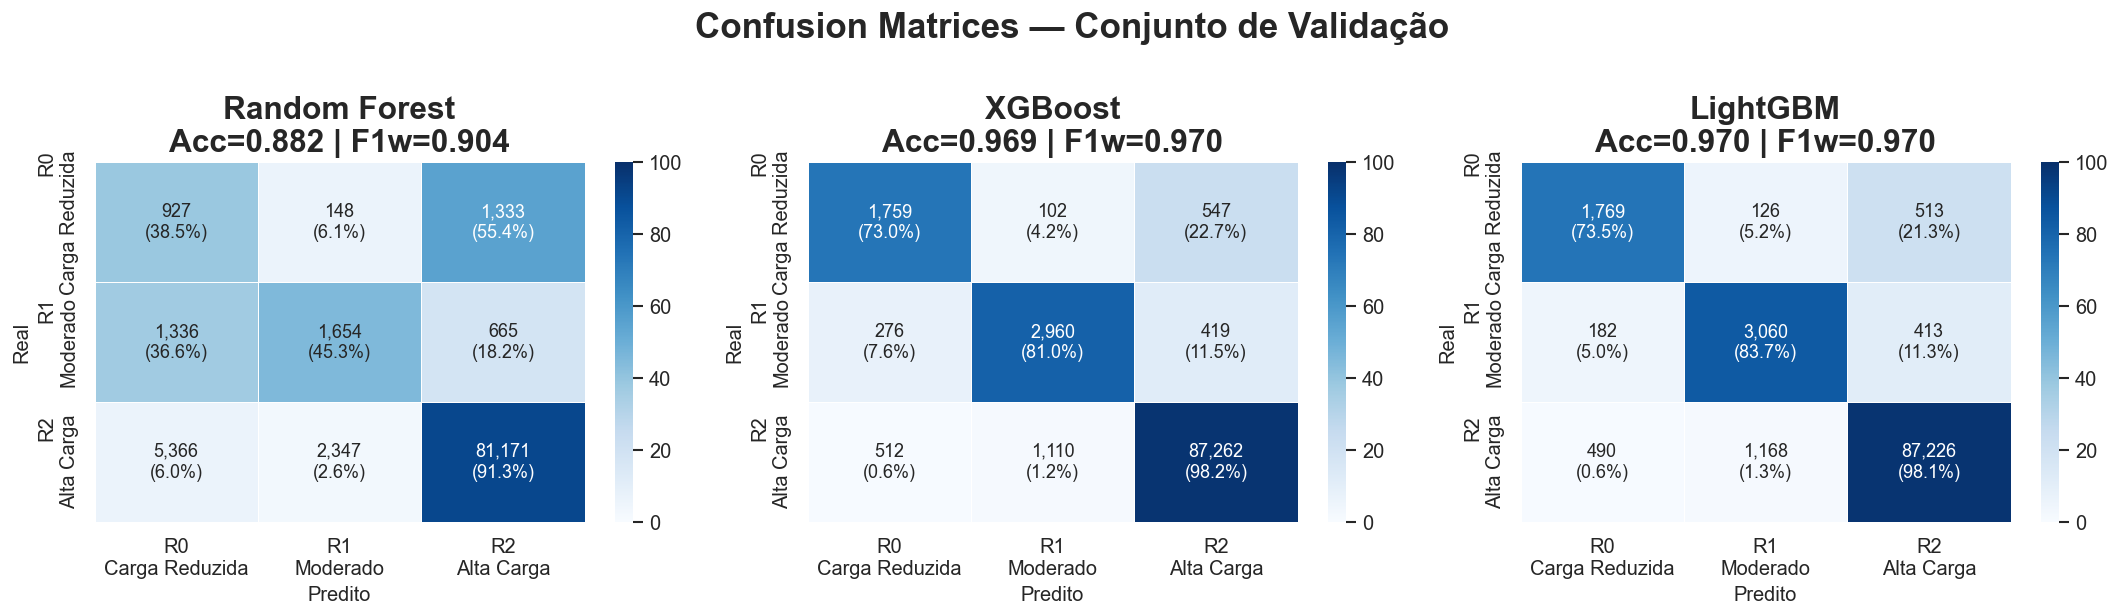

In [7]:
# Confusion matrices dos 3 modelos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nome, y_pred) in zip(axes, [
    ("Random Forest", y_val_pred_rf),
    ("XGBoost", y_val_pred_xgb),
    ("LightGBM", y_val_pred_lgbm),
]):
    cm = confusion_matrix(y_val, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    labels_cm = [f"R{r}\n{REGIME_NAMES[r]}" for r in range(3)]
    
    # Anotações com contagem e percentual
    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)"
    
    sns.heatmap(cm_pct, annot=annot, fmt="", cmap="Blues", ax=ax,
                xticklabels=labels_cm, yticklabels=labels_cm,
                linewidths=0.5, vmin=0, vmax=100)
    acc = accuracy_score(y_val, y_pred)
    f1w = f1_score(y_val, y_pred, average="weighted")
    ax.set_title(f"{nome}\nAcc={acc:.3f} | F1w={f1w:.3f}", fontweight="bold")
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")

fig.suptitle("Confusion Matrices — Conjunto de Validação", fontsize=21, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S2c_01_confusion_matrices_val.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "confusion_matrices_val", fig, "S2c_01_confusion_matrices_val.png")
plt.show()

## 6b. Métricas por Regime e por Modelo (Validação)

**Objetivo:** Visualizar precisão, cobertura (recall) e F1-Score de cada regime para cada modelo, lado a lado.

**Justificativa:** As métricas globais (accuracy, F1-macro) podem mascarar fragilidades em regimes minoritários. Esta visualização expõe onde cada modelo é forte e fraco, permitindo uma escolha informada do melhor modelo.

MÉTRICAS POR REGIME E POR MODELO (Validação):
                    Cobertura                       F1-Score                       Precisão                      
Modelo               LightGBM Random Forest XGBoost LightGBM Random Forest XGBoost LightGBM Random Forest XGBoost
Regime                                                                                                           
R0 (Carga Reduzida)     0.735         0.385   0.730    0.730         0.185   0.710    0.725         0.122   0.691
R1 (Moderado)           0.837         0.453   0.810    0.764         0.424   0.756    0.703         0.399   0.709
R2 (Alta Carga)         0.981         0.913   0.982    0.985         0.944   0.985    0.989         0.976   0.989
[db_utils] Imagem 'metricas_por_regime' salva para etapa s2c


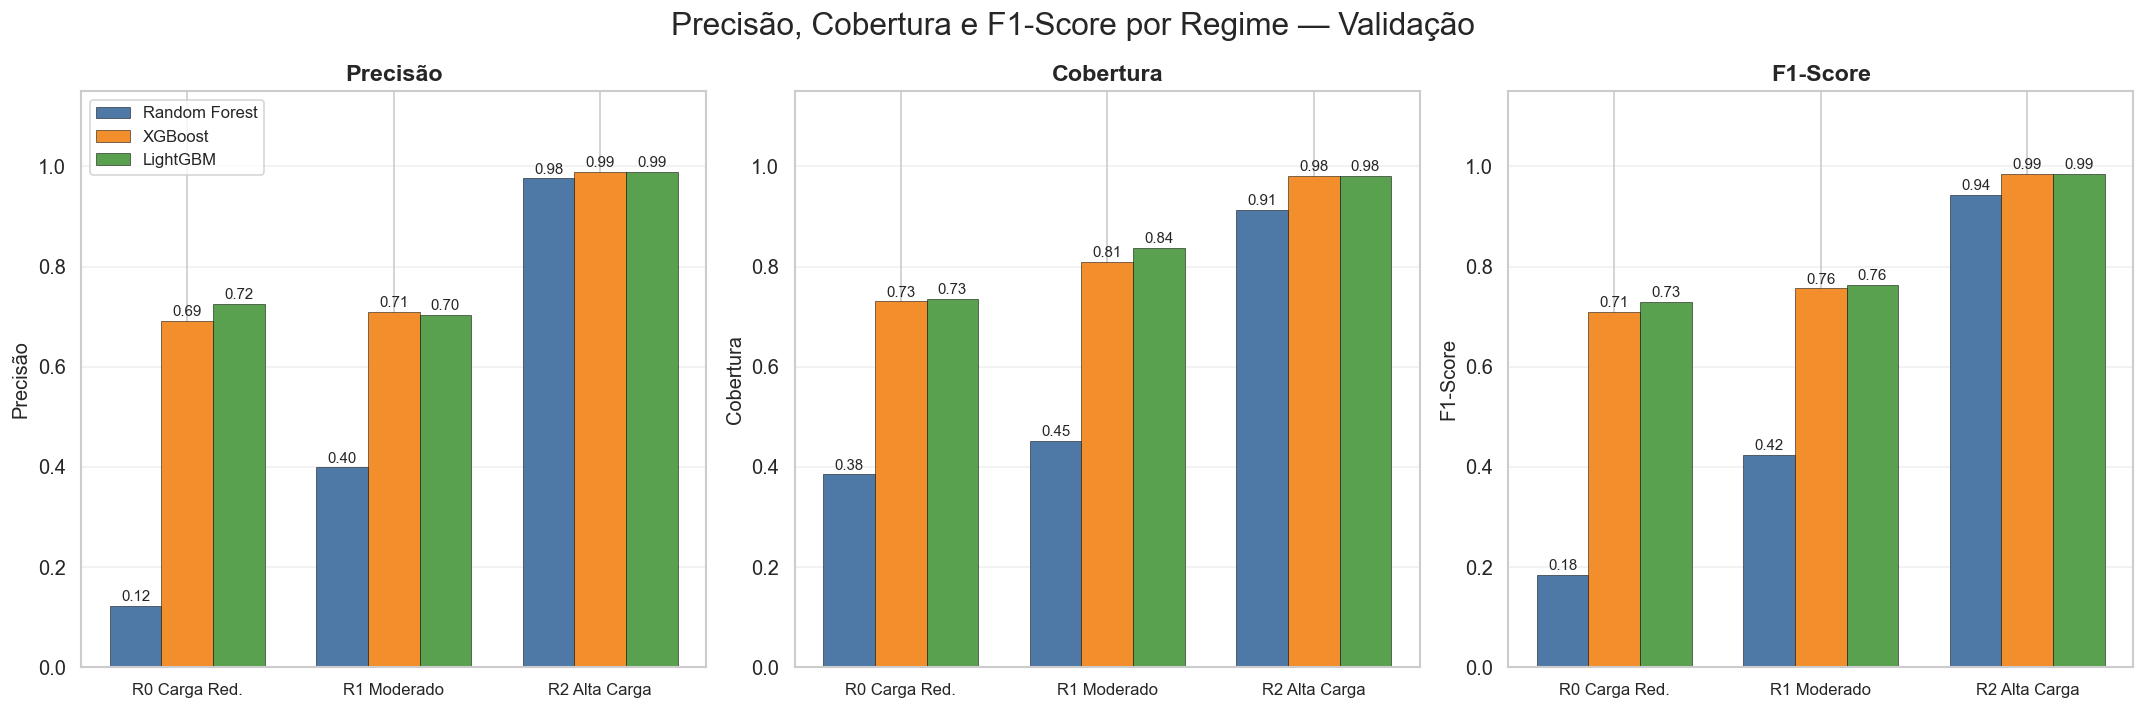

In [8]:
# Métricas por regime por modelo — tabela e gráfico
from sklearn.metrics import precision_recall_fscore_support

# Calcular precisão, cobertura e F1 por regime para cada modelo
metricas_por_regime = []
for nome, y_pred in [
    ("Random Forest", y_val_pred_rf),
    ("XGBoost", y_val_pred_xgb),
    ("LightGBM", y_val_pred_lgbm),
]:
    prec, rec, f1, sup = precision_recall_fscore_support(y_val, y_pred, labels=[0,1,2], zero_division=0)
    for r in range(3):
        metricas_por_regime.append({
            "Modelo": nome,
            "Regime": f"R{r} ({REGIME_NAMES[r]})",
            "Regime_id": r,
            "Precisão": prec[r],
            "Cobertura": rec[r],
            "F1-Score": f1[r],
            "Suporte": int(sup[r]),
        })

df_regime = pd.DataFrame(metricas_por_regime)

# Tabela formatada
print("MÉTRICAS POR REGIME E POR MODELO (Validação):")
print("=" * 90)
pivot = df_regime.pivot_table(
    index=["Regime"], columns="Modelo",
    values=["Precisão", "Cobertura", "F1-Score"],
    aggfunc="first"
)
print(pivot.round(3).to_string())

# Gráfico: 3 subplots (Precisão, Cobertura, F1) com barras por modelo
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metricas_nomes = ["Precisão", "Cobertura", "F1-Score"]
cores_modelo = {"Random Forest": "#4e79a7", "XGBoost": "#f28e2b", "LightGBM": "#59a14f"}
regimes_labels = ["R0 Carga Red.", "R1 Moderado", "R2 Alta Carga"]

for ax, metrica in zip(axes, metricas_nomes):
    x = np.arange(3)
    width = 0.25
    modelos_list = ["Random Forest", "XGBoost", "LightGBM"]

    for j, modelo in enumerate(modelos_list):
        vals = df_regime[df_regime["Modelo"] == modelo][metrica].values
        bars = ax.bar(x + j * width, vals, width, label=modelo,
                      color=cores_modelo[modelo], edgecolor="black", linewidth=0.3)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f"{val:.2f}", ha="center", fontsize=9)

    ax.set_xticks(x + width)
    ax.set_xticklabels(regimes_labels, fontsize=10)
    ax.set_ylabel(metrica, fontsize=12)
    ax.set_title(metrica, fontsize=14, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.grid(True, alpha=0.3, axis="y")

axes[0].legend(fontsize=10)
fig.suptitle("Precisão, Cobertura e F1-Score por Regime — Validação", fontsize=19)
plt.tight_layout()

fig.savefig(FIGURES_DIR / "S2c_04_metricas_por_regime.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "metricas_por_regime", fig, "S2c_04_metricas_por_regime.png")
plt.show()

## 7. Avaliação no Conjunto de TESTE

**Objetivo:** Realizar a avaliação definitiva do melhor modelo no conjunto de teste, composto por dados nunca utilizados durante o treinamento ou a seleção de hiperparâmetros.

Aplico o modelo selecionado (maior F1-weighted na validação) ao conjunto de teste para obter a métrica final de desempenho. Gero o classification report com precision, recall e F1-score por classe (regime), além da confusion matrix correspondente.

**Justificativa:** O conjunto de teste simula dados futuros que o modelo encontraria em produção. Por não ter participado de nenhuma etapa de ajuste, esta avaliação fornece a estimativa mais realista da capacidade de generalização do classificador. Esta é a métrica que reporto como resultado final do projeto.

Avaliando LightGBM no conjunto de TESTE (94,949 registros)...

  Accuracy:     0.9847
  F1-macro:     0.8698
  F1-weighted:  0.9861
  AUC-weighted: 0.9956

                precision    recall  f1-score   support

Carga Reduzida       0.91      0.85      0.88       250
      Moderado       0.62      0.92      0.74      2175
    Alta Carga       1.00      0.99      0.99     92524

      accuracy                           0.98     94949
     macro avg       0.84      0.92      0.87     94949
  weighted avg       0.99      0.98      0.99     94949

[db_utils] Imagem 'confusion_matrix_teste' salva para etapa s2c


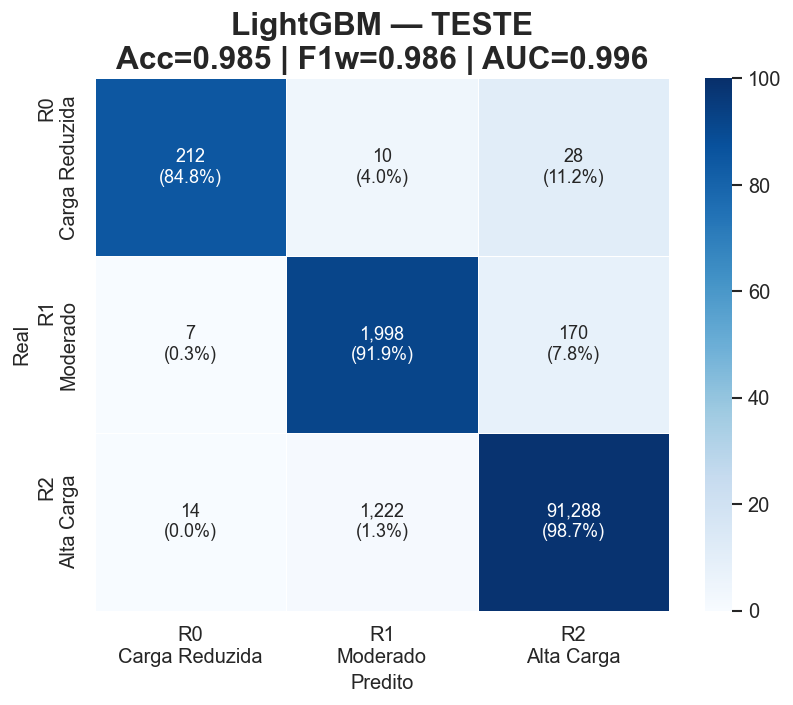

In [9]:
# Selecionar melhor modelo
modelos = {"Random Forest": rf_best, "XGBoost": xgb_best, "LightGBM": lgbm_best}
best_model = modelos[melhor_idx]

print(f"Avaliando {melhor_idx} no conjunto de TESTE ({len(X_test):,} registros)...")
print("=" * 60)

y_test_pred = best_model.predict(X_test_s)
y_test_proba = best_model.predict_proba(X_test_s)

acc_test = accuracy_score(y_test, y_test_pred)
f1m_test = f1_score(y_test, y_test_pred, average="macro")
f1w_test = f1_score(y_test, y_test_pred, average="weighted")
try:
    auc_test = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='weighted')
except:
    auc_test = np.nan

print(f"\n  Accuracy:     {acc_test:.4f}")
print(f"  F1-macro:     {f1m_test:.4f}")
print(f"  F1-weighted:  {f1w_test:.4f}")
print(f"  AUC-weighted: {auc_test:.4f}")
print(f"\n{classification_report(y_test, y_test_pred, target_names=[REGIME_NAMES[r] for r in range(3)])}")

# Confusion matrix no teste
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
cm_test = confusion_matrix(y_test, y_test_pred)
cm_test_pct = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True) * 100
labels_cm = [f"R{r}\n{REGIME_NAMES[r]}" for r in range(3)]
annot = np.empty_like(cm_test, dtype=object)
for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        annot[i, j] = f"{cm_test[i,j]:,}\n({cm_test_pct[i,j]:.1f}%)"
sns.heatmap(cm_test_pct, annot=annot, fmt="", cmap="Blues", ax=ax,
            xticklabels=labels_cm, yticklabels=labels_cm,
            linewidths=0.5, vmin=0, vmax=100)
ax.set_xlabel("Predito")
ax.set_ylabel("Real")
ax.set_title(f"{melhor_idx} — TESTE\nAcc={acc_test:.3f} | F1w={f1w_test:.3f} | AUC={auc_test:.3f}",
             fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S2c_02_confusion_matrix_teste.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "confusion_matrix_teste", fig, "S2c_02_confusion_matrix_teste.png")
plt.show()

## 8. SHAP — Interpretabilidade

**Objetivo:** Utilizar SHAP (SHapley Additive exPlanations) para interpretar quais variáveis de processo mais influenciam as predições do modelo selecionado.

Aplico o `TreeExplainer` do SHAP, que explora a estrutura interna das árvores para calcular a contribuição marginal de cada feature em cada predição. Computo os SHAP values sobre uma amostra de 5.000 registros do conjunto de validação para viabilidade computacional. Gero o gráfico de barras com a média dos valores absolutos de SHAP (top 20 features).

**Parâmetros:**
- Amostra: 5.000 registros (seleção aleatória com seed fixa)
- Explainer: `TreeExplainer` (exato para modelos baseados em árvores)

**Justificativa:** A análise SHAP é fundamental para a interpretabilidade do modelo em contexto industrial. Identificar quais variáveis de processo dirigem a classificação dos regimes operacionais permite que engenheiros e operadores compreendam os fatores determinantes de cada regime, conferindo confiança ao modelo e orientando ações de controle de processo.

Calculando SHAP values (amostra de 5.000 registros)...
SHAP calculado em 4s
Shape shap_values: (5000, 105, 3)
[db_utils] Imagem 'shap_importance' salva para etapa s2c


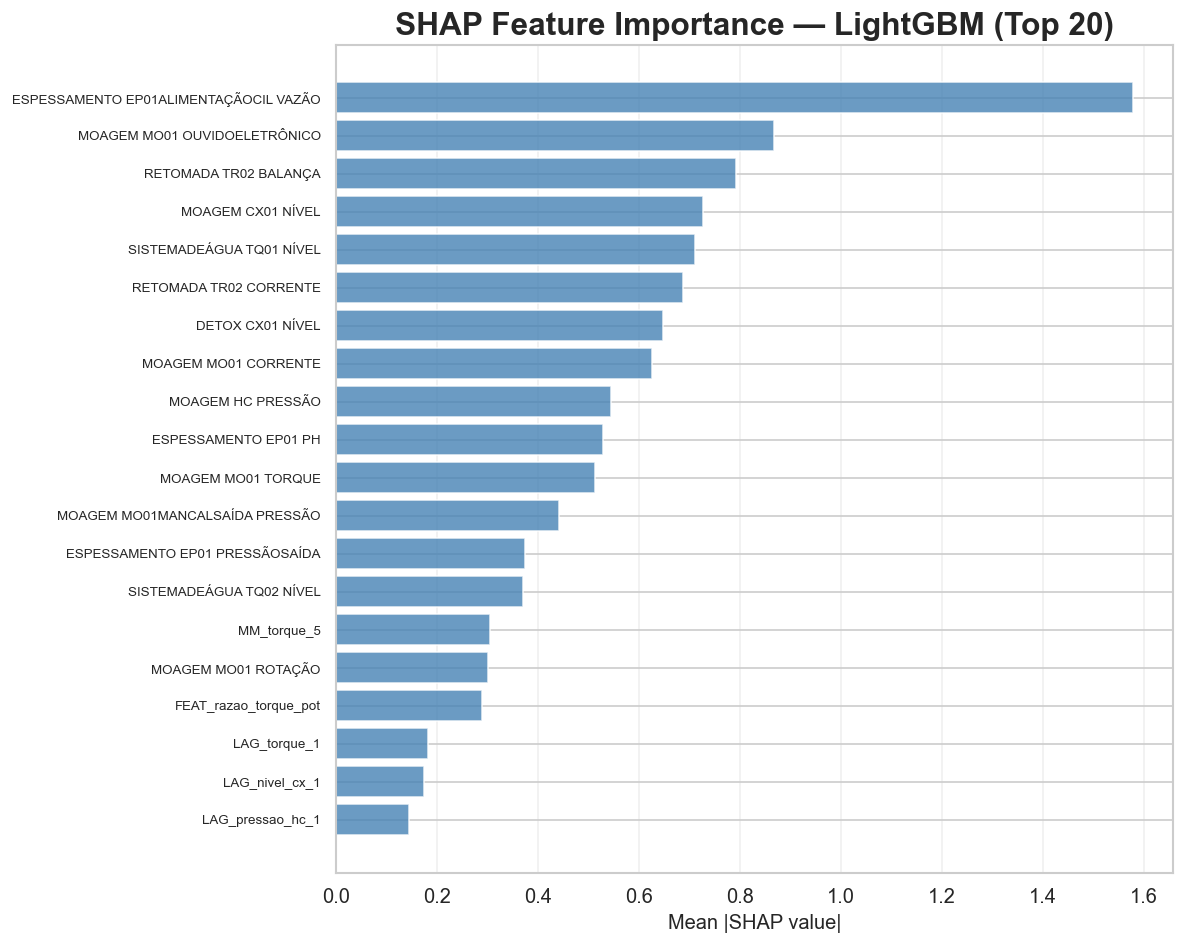


Top 10 features (SHAP):
   1. ESPESSAMENTO EP01ALIMENTAÇÃOCIL VAZÃO (SHAP médio = 1.5789)
   2. MOAGEM MO01 OUVIDOELETRÔNICO   (SHAP médio = 0.8674)
   3. RETOMADA TR02 BALANÇA          (SHAP médio = 0.7912)
   4. MOAGEM CX01 NÍVEL              (SHAP médio = 0.7258)
   5. SISTEMADEÁGUA TQ01 NÍVEL       (SHAP médio = 0.7099)
   6. RETOMADA TR02 CORRENTE         (SHAP médio = 0.6873)
   7. DETOX CX01 NÍVEL               (SHAP médio = 0.6477)
   8. MOAGEM MO01 CORRENTE           (SHAP médio = 0.6245)
   9. MOAGEM HC PRESSÃO              (SHAP médio = 0.5436)
  10. ESPESSAMENTO EP01 PH           (SHAP médio = 0.5291)


In [10]:
import re
import shap

print("Calculando SHAP values (amostra de 5.000 registros)...")
t_shap = time.time()

# Amostra para SHAP (economizar tempo)
np.random.seed(42)
idx_sample = np.random.choice(len(X_val_s), size=min(5000, len(X_val_s)), replace=False)
X_shap = X_val_s.iloc[idx_sample]

# Nomes curtos para visualização
def nome_curto_feat(col):
    """Remove sufixo _pipoint e prefixo numérico, mantendo nome único."""
    if col.endswith("_pipoint"):
        nome = col.replace("_pipoint", "").strip()
        nome = re.sub(r"^\d{4}_", "", nome)
        nome = re.sub(r"\s*_\s*", " ", nome).strip()
        return nome
    return col

nomes_curtos = [nome_curto_feat(c) for c in feature_cols]
X_shap_renamed = X_shap.copy()
X_shap_renamed.columns = nomes_curtos

# SHAP explainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

elapsed_shap = time.time() - t_shap
print(f"SHAP calculado em {elapsed_shap:.0f}s")
print(f"Shape shap_values: {np.array(shap_values).shape}")

# Calcular importância média absoluta por feature
sv = np.array(shap_values)
if sv.ndim == 3:
    # (classes, samples, features) ou (samples, features, classes)
    if sv.shape[0] == 3:  # (classes, samples, features)
        mean_abs = np.abs(sv).mean(axis=(0, 1))  # média sobre classes e amostras
    else:  # (samples, features, classes)
        mean_abs = np.abs(sv).mean(axis=(0, 2))  # média sobre amostras e classes
elif sv.ndim == 2:
    mean_abs = np.abs(sv).mean(axis=0)
else:
    mean_abs = np.abs(sv).flatten()

# Summary plot (barras) - usar feature importance manual
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
top_n = 20
sorted_idx = np.argsort(mean_abs)[::-1][:top_n]
ax.barh(range(top_n), mean_abs[sorted_idx][::-1], color="steelblue", alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels([nomes_curtos[int(i)] for i in sorted_idx[::-1]], fontsize=8)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title(f"SHAP Feature Importance — {melhor_idx} (Top {top_n})", fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S2c_03_shap_importance.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "shap_importance", fig, "S2c_03_shap_importance.png")
plt.show()

# Top 10 features
top_idx_10 = np.argsort(mean_abs)[::-1][:10]
print(f"\nTop 10 features (SHAP):")
for rank, idx_val in enumerate(top_idx_10, 1):
    i = int(idx_val)
    print(f"  {rank:2d}. {nomes_curtos[i]:30s} (SHAP médio = {mean_abs[i]:.4f})")


## 9. Salvamento

**Objetivo:** Persistir todos os artefatos de treinamento em disco e no PostgreSQL para reprodutibilidade e consumo pelo dashboard.

Salvo os três modelos treinados como arquivos `.pkl` via joblib, além do modelo final selecionado (`classificador_final.pkl`). As predições do conjunto de teste com probabilidades por classe são exportadas em parquet, e a tabela comparativa de métricas em CSV.

**Persistência no PostgreSQL:**
- `s2_resultados_modelos`: métricas de todos os modelos nos conjuntos de validação e teste (Accuracy, F1-macro, F1-weighted, Precision, Recall, AUC).
- `s2_importancia_features`: ranking de importância das features do melhor modelo.
- Figuras salvas em disco e no banco via `salvar_imagem`.

**Justificativa:** A persistência estruturada permite que o dashboard consuma os resultados diretamente do banco, enquanto os arquivos em disco garantem reprodutibilidade offline e facilidade de versionamento dos modelos.

In [11]:
# Salvar todos os modelos
joblib.dump(rf_best, MODELS_DIR / "rf_classificador.pkl")
joblib.dump(xgb_best, MODELS_DIR / "xgb_classificador.pkl")
joblib.dump(lgbm_best, MODELS_DIR / "lgbm_classificador.pkl")
joblib.dump(best_model, MODELS_DIR / "classificador_final.pkl")
print(f"Modelos salvos em {MODELS_DIR}")

# Salvar predições do teste
pred_test = pd.DataFrame({
    "regime_real": y_test.values,
    "regime_pred": y_test_pred,
    "proba_R0": y_test_proba[:, 0],
    "proba_R1": y_test_proba[:, 1],
    "proba_R2": y_test_proba[:, 2],
}, index=X_test.index)
pred_test.to_parquet(DATA_LABEL / "predicoes_teste.parquet")
print(f"Predições do teste: {DATA_LABEL / 'predicoes_teste.parquet'}")

# Salvar tabela comparativa
df_resultados.to_csv(DATA_LABEL / "comparacao_modelos.csv")
print(f"Comparação: {DATA_LABEL / 'comparacao_modelos.csv'}")

# ==============================================================================
# Persistência no PostgreSQL
# ==============================================================================
print("\nSalvando no PostgreSQL...")

# 1. s2_resultados_modelos — métricas de todos os modelos (val + teste)
resultados_db = []
# Resultados de validação (já no df_resultados)
for modelo in df_resultados.index:
    for metrica in ["Accuracy", "F1-macro", "F1-weighted", "Precision-macro", "Recall-macro", "AUC-weighted"]:
        resultados_db.append({
            "modelo": modelo,
            "conjunto": "validacao",
            "metrica": metrica,
            "valor": df_resultados.loc[modelo, metrica],
        })
# Resultados de teste (melhor modelo)
for metrica, valor in [
    ("Accuracy", accuracy_score(y_test, y_test_pred)),
    ("F1-macro", f1_score(y_test, y_test_pred, average="macro")),
    ("F1-weighted", f1_score(y_test, y_test_pred, average="weighted")),
    ("Precision-macro", precision_score(y_test, y_test_pred, average="macro")),
    ("Recall-macro", recall_score(y_test, y_test_pred, average="macro")),
    ("AUC-weighted", roc_auc_score(y_test, y_test_proba, multi_class="ovr", average="weighted")),
]:
    resultados_db.append({
        "modelo": melhor_idx,
        "conjunto": "teste",
        "metrica": metrica,
        "valor": valor,
    })
salvar_dataframe(pd.DataFrame(resultados_db), "s2_resultados_modelos")

# 2. s2_importancia_features — feature importance do melhor modelo
imp = best_model.feature_importances_
df_imp = pd.DataFrame({
    "modelo": melhor_idx,
    "feature": feature_cols,
    "importancia": imp,
})
df_imp = df_imp.sort_values("importancia", ascending=False).reset_index(drop=True)
df_imp["ranking"] = range(1, len(df_imp) + 1)
salvar_dataframe(df_imp, "s2_importancia_features")

# 3. s2c_predicoes_teste — predições completas do melhor modelo no teste
salvar_dataframe(pred_test.reset_index(), "s2c_predicoes_teste", modo="replace")

print("\nDados de treinamento salvos no PostgreSQL.")

Modelos salvos em C:\ScriptsDatamindsPIP\4-Projeto aplicado\models
Predições do teste: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\labeled\predicoes_teste.parquet
Comparação: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\labeled\comparacao_modelos.csv

Salvando no PostgreSQL...
[db_utils] 24 linhas salvas em otimizar_moagem_aura.s2_resultados_modelos
[db_utils] 105 linhas salvas em otimizar_moagem_aura.s2_importancia_features
[db_utils] 94,949 linhas salvas em otimizar_moagem_aura.s2c_predicoes_teste

Dados de treinamento salvos no PostgreSQL.


## 10. Resumo

**Objetivo:** Consolidar os principais resultados do treinamento de modelos de classificação supervisionada.

Apresento um resumo com os três modelos treinados e suas métricas comparativas na validação, o modelo selecionado e seu desempenho definitivo no conjunto de teste (F1-weighted), as 5 features mais influentes segundo a análise SHAP, o tempo de treinamento de cada modelo e a utilização de GPU. Este resumo serve como referência rápida para o relatório do projeto e para decisões subsequentes sobre implantação do classificador.

In [12]:
elapsed = time.time() - t0
print("\n" + "=" * 60)
print("  RESUMO — TREINAMENTO DE MODELOS (S2c)")
print("=" * 60)
print(f"  Tempo total: {elapsed:.0f}s ({elapsed/60:.1f} min)")
print(f"  Features: {len(feature_cols)}")
print(f"\n  COMPARAÇÃO (VALIDAÇÃO):")
print(df_resultados[["Accuracy", "F1-weighted", "AUC-weighted"]].round(4).to_string())
print(f"\n  ► MELHOR MODELO: {melhor_idx}")
print(f"\n  DESEMPENHO NO TESTE:")
print(f"    Accuracy:     {acc_test:.4f}")
print(f"    F1-macro:     {f1m_test:.4f}")
print(f"    F1-weighted:  {f1w_test:.4f}")
print(f"    AUC-weighted: {auc_test:.4f}")
print(f"\n  Top 5 features (SHAP):")
for rank, idx_val in enumerate(top_idx_10[:5], 1):
    i = int(idx_val)
    print(f"    {rank}. {nomes_curtos[i]}")
print(f"\n  Modelos salvos: {MODELS_DIR}")
print(f"  Figuras: {len(list(FIGURES_DIR.glob('*.png')))} em {FIGURES_DIR}")
print("=" * 60)


  RESUMO — TREINAMENTO DE MODELOS (S2c)
  Tempo total: 2544s (42.4 min)
  Features: 105

  COMPARAÇÃO (VALIDAÇÃO):
               Accuracy  F1-weighted  AUC-weighted
Modelo                                            
Random Forest    0.8821       0.9043        0.9182
XGBoost          0.9688       0.9696        0.9891
LightGBM         0.9695       0.9704        0.9897

  ► MELHOR MODELO: LightGBM

  DESEMPENHO NO TESTE:
    Accuracy:     0.9847
    F1-macro:     0.8698
    F1-weighted:  0.9861
    AUC-weighted: 0.9956

  Top 5 features (SHAP):
    1. ESPESSAMENTO EP01ALIMENTAÇÃOCIL VAZÃO
    2. MOAGEM MO01 OUVIDOELETRÔNICO
    3. RETOMADA TR02 BALANÇA
    4. MOAGEM CX01 NÍVEL
    5. SISTEMADEÁGUA TQ01 NÍVEL

  Modelos salvos: C:\ScriptsDatamindsPIP\4-Projeto aplicado\models
  Figuras: 9 em C:\ScriptsDatamindsPIP\4-Projeto aplicado\figures\02_sprint2


In [13]:
# ==============================================================================
# Exportar notebook para HTML (com todos os outputs)
# ==============================================================================
from pathlib import Path
from IPython.display import display, Javascript
import time

# 1. Forçar salvamento do notebook (grava outputs em disco)
display(Javascript("IPython.notebook.save_checkpoint()"))
time.sleep(3)  # Aguardar gravação

# 2. Exportar o .ipynb salvo para HTML
from nbconvert import HTMLExporter
import nbformat

_nb_path = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado\notebooks\02_sprint2\c_treinamento_modelos.ipynb")
_html_dir = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado\html")
_html_dir.mkdir(parents=True, exist_ok=True)

with open(_nb_path, encoding="utf-8") as _f:
    _nb_node = nbformat.read(_f, as_version=4)

_exporter = HTMLExporter()
_exporter.exclude_input = True  # Ocultar código, manter outputs
(_html_body, _) = _exporter.from_notebook_node(_nb_node)

_out_path = _html_dir / "c_treinamento_modelos.html"
_out_path.write_text(_html_body, encoding="utf-8")
print("HTML exportado:", _out_path)

<IPython.core.display.Javascript object>

HTML exportado: C:\ScriptsDatamindsPIP\4-Projeto aplicado\html\c_treinamento_modelos.html
